# Vector Datasets and `geopandas`

## Introduction

Now that we understand the basic `shapely` datatypes, we can see how this is incorporated into geospatial data manipulation using [the `geopandas` library](https://geopandas.org/en/stable/index.html). A lot of the concepts you are now familiar with from `pandas` will return: but now, we are further enabled make use of geospatial data and analysis techniques.

Geopandas is, by convention, imported as `gpd`:

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt

## Loading and Inspecting a `GeoDataFrame`

One of the sample datasets we will be using in this session is the [Natural Earth 50 m country dataset](https://www.naturalearthdata.com/downloads/50m-cultural-vectors/50m-admin-0-countries-2/), which attempts to consolidate the messy _de facto_ country boundaries across the world into a single dataset (this isn't perfect and requires making difficult decisions, as outlined in their [disputed boundaries policy](https://www.naturalearthdata.com/about/disputed-boundaries-policy), but we are using it as a useful open-source base dataset for now). A slightly trimmed version for this class is made available [at the following link](https://raw.githubusercontent.com/trchudley/geospatial-scientific-computing/main/week/03/nat_earth_countries.gpkg). Save this dataset as `nat_earth_countries.gpkg` within the same directory as your Jupyter Notebook.

Note that the file ends in `.gpkg`: this is "geopackage" file. As discussed in the lecture, there are a variety of other competing data files for geospatial vector data, including shapefile (`.shp`, and required supporting files), GeoJSON (`json`), or geoparquet (`.parquet`). GeoPandas should be able to take most file types you throw at it: however, I would recommend that, without a good reason, you save your own datasets by default as a GeoPackage.

You can pass your target filepath to the `gpd.read_file()` function to load the file as a `GeoDataFrame`.

In [39]:
filepath = 'nat_earth_countries.gpkg'

# By convention, we use the variable name `gdf` to refer to a GeoDataFrame.
countries_gdf = gpd.read_file(filepath)

countries_gdf.set_index('ADMIN', inplace=True)

Let's inspect this dataframe:

In [40]:
countries_gdf

,CONTINENT,REGION_UN,SUBREGION,POP_EST,POP_RANK,GDP_MD,INCOME_GRP,ISO_A3,ISO_A2,geometry
ADMIN,,,,,,,,,,
Zimbabwe,Africa,Africa,Eastern Africa,14645468.0,14,21440,5. Low income,ZWE,ZW,"MULTIPOLYGON (((31.28789 -22.40205, 31.19727 -..."
Zambia,Africa,Africa,Eastern Africa,17861030.0,14,23309,4. Lower middle income,ZMB,ZM,"MULTIPOLYGON (((30.39609 -15.64307, 30.25068 -..."
Yemen,Asia,Asia,Western Asia,29161922.0,15,22581,4. Lower middle income,YEM,YE,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
Vietnam,Asia,Asia,South-Eastern Asia,96462106.0,16,261921,4. Lower middle income,VNM,VN,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
Venezuela,South America,Americas,South America,28515829.0,15,482359,3. Upper middle income,VEN,VE,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."
...,...,...,...,...,...,...,...,...,...,...
Afghanistan,Asia,Asia,Southern Asia,38041754.0,15,19291,5. Low income,AFG,AF,"MULTIPOLYGON (((66.52227 37.34849, 66.82773 37..."
Siachen Glacier,Asia,Asia,Southern Asia,6000.0,5,15,4. Lower middle income,-99,-99,"MULTIPOLYGON (((77.04863 35.10991, 77.00449 35..."
Antarctica,Antarctica,Antarctica,Antarctica,4490.0,4,898,2. High income: nonOECD,ATA,AQ,"MULTIPOLYGON (((-45.71777 -60.5209, -45.49971 ..."


This will look familiar from our work using pandas. A lot of the columns are self-explantory: administrative name, continent, estimation populatin, etc. However, the key column is on the far right: the `geometry` column. This has been created by `geopandas` from the geospatial data within the geopackage file. You will note that it appears to contain `shapely` `MultiPolygon` objects.

As a result, when we try and do a simple `countries_gdf.plot()`, rather than getting a line plot or similar, we get a something quite different...

<Axes: >

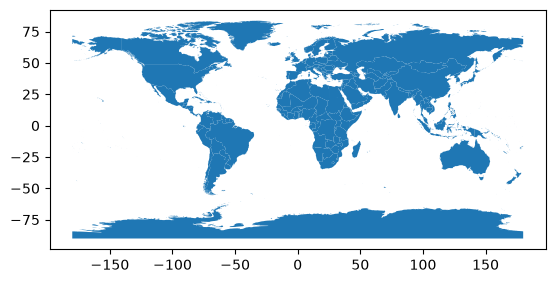

In [24]:
countries_gdf.plot()

Great - we are able to visualise our geospatial data, and it works using `matplotlib` as well!


## CRS

We can see from the axes of the graph that the `x` coordinates range from `-180.0` to `180.0`, and the `y` coordinates range from `-90` to `+90`. Hence, it is likely the case that our units are in degrees of latitude and longitude. We can check this using the special `GeoDataFrame` attribute `.crs`:

In [29]:
countries_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Yes: our axis are in latitude and longitude. The specific CRS is [EPSG:4326](https://epsg.io/4326): I mentioned in the lecture that this can be considered the 'default' latitutde/longitude projection.

However, in the previous section I raised some problems with measuring in latitude and longitude. For instance, in most of our applications it doesn't make much sense to calculate distances and areas in degrees. It would be useful to find a CRS that had units of metres.

Let's switch to an [equal earth projection (EPSG:8857)](https://epsg.io/8857). We can convert projections using the `.to_crs()` function,.


In [42]:
countries_gdf_projected = countries_gdf.to_crs(epsg=8857)

Let's plot it:

<Axes: >

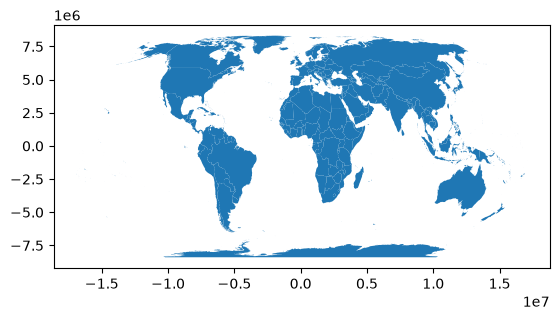

In [32]:
countries_gdf_projected.plot()

Now, our units look realistic for being metres. However, you might notice that the shapes of the countries now appear distorted, particularly in the 'corners' of the globe. The original CRS was a _conformal_ projection, which preseved local shape and angels, but inflated the apparent size of countries away from the poles. The new CRS is _equal-area_, which preseves area and size but distorts local shapes and angles. Other mutually exclusive projection types exist - for instance, being _azimuthal_ (preseves distance from a central point).

These nature of these type of projections have been the subject of [a recent vote at the UN](https://www.bbc.co.uk/news/articles/ce30vp55dnlo). However, all projections have a purpose: you will still see the much-maligned Mercator projection [in a modern web format](https://epsg.io/3857) for web mapping purposes, as 'zooming in' to local areas on a web map requires angles to be preserved (_conformal_ projections). Some projections aim to be a qualitative balance of these types (known as a _compromise_ projection) - losing both conformal and equal-area properties, but providing a hopefully aesthetic balance between the two.

Anyway, now that we have a projection useful for calculating area, we can use the `.area` attribute of a `GeoDataFrame` to calculate the area (in CRS units) for our countries:


In [43]:
countries_gdf_projected.area

ADMIN
Zimbabwe           3.889936e+11
Zambia             7.527751e+11
Yemen              4.525663e+11
Vietnam            3.278475e+11
Venezuela          9.104385e+11
                       ...     
Afghanistan        6.418439e+11
Siachen Glacier    2.118152e+09
Antarctica         1.235647e+13
Sint Maarten       4.170159e+07
Tuvalu             1.020798e+07
Length: 242, dtype: float64

These units are in metres: let's add a new `'area'` column to the table, but divide by 1,000,000 m<sup>2</sup> to convert to km<sup>2</sup>.

In [44]:
countries_gdf_projected['area_km2'] = countries_gdf_projected.area / 10**6

By providing a `column` variable to the `plot()` function, we can actually colour-code our countries according to values:

<Axes: >

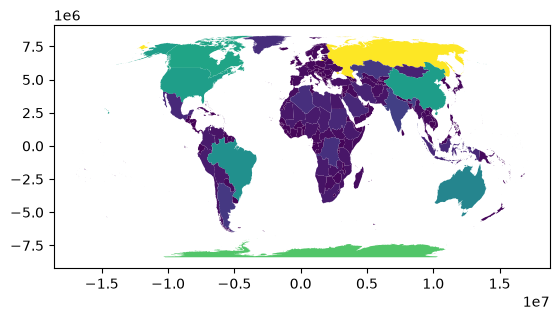

In [53]:
countries_gdf_projected.plot(column='area_km2')

For neat plotting purposes, we can add the usual essentials, and get a colour bar by using the `legend=True` argument for `plot()`.

Text(51.49313241069312, 0.5, 'Northing (m)')

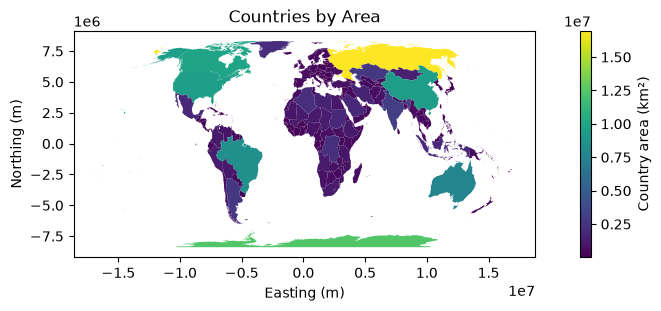

In [58]:

fig, ax = plt.subplots(figsize=(7,3), layout='constrained')

countries_gdf_projected.plot(
    column='area_km2', 
    cmap='viridis', 
    ax=ax, 
    legend=True,
    legend_kwds={'label': "Country area (km²)"}  # We can add a label to the legend using the `legend_kwds` parameter
)

ax.set_title('Countries by Area') 
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

We could even now calculate population density:

Text(68.87032308082426, 0.5, 'Northing (m)')

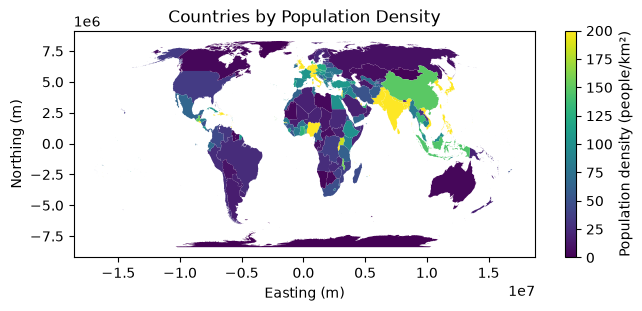

In [ ]:
# calculate and plot population density

countries_gdf_projected['pop_density_km2'] = countries_gdf_projected['POP_EST'] / countries_gdf_projected['area_km2']

fig, ax = plt.subplots(figsize=(7,3), layout='constrained')

countries_gdf_projected.plot(
    column='pop_density_km2',
    vmin=0,
    vmax=200,
    cmap='viridis',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Population density (people/km²)"}
)

ax.set_title('Countries by Population Density')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

Because of the wide disparity between densities (the densest micronations have densities > 1000 people/km2), note we have used the `vmin` and `vmax` argument to manually set the bounds of our colour bar.

Why not try plotting another data column, such as `POP_EST` (estimated population)?

## Combining Pandas operations

We can use our existing Pandas skills - such as index slicing and grouping - to get different dataframes.

For now, we will revert to using the original latitude/longitude projection (`countries_gdf`).

If we're interested in continents rather than countries, we could the `CONTINENT` column to group the individual polygons.

A quick tip - we can use the Pandas `.unique()` function to extract all individual group names.

In [60]:
countries_gdf['CONTINENT'].unique()

array(['Africa', 'Asia', 'South America', 'Europe', 'Oceania',
       'North America', 'Seven seas (open ocean)', 'Antarctica'],
      dtype=object)

And even get the number of countries within each continent:

CONTINENT
Africa                     54
Asia                       53
Europe                     50
North America              38
Oceania                    25
South America              13
Seven seas (open ocean)     8
Antarctica                  1
Name: count, dtype: int64

And plot them!

<Axes: title={'center': 'Number of countries by continent'}, xlabel='CONTINENT'>

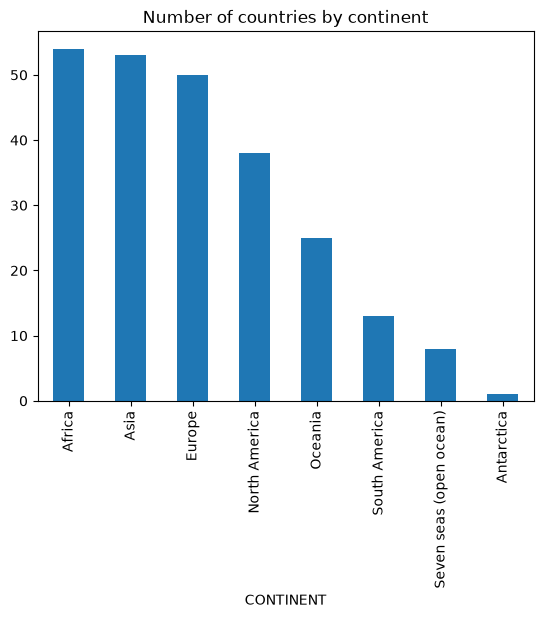

In [63]:
countries_gdf['CONTINENT'].value_counts().plot(kind='bar', title='Number of countries by continent')

Note: as this dataset adds additional polygons that aren't strictly countries, so we have more rows that we do countries. Despite 195 recognised countries in the world, this dataset has 242 rows:

In [70]:
len(countries_gdf)

242

If we wanted to merge all of our countries into continents, we can still use `groupby` to perform calculations:

In [ ]:
# groupby continent and sum the area of countries in each continent
continent_area = countries_gdf_projected.groupby('CONTINENT')['area_km2'].sum()

continent_area

CONTINENT
Africa                     2.989005e+07
Antarctica                 1.235647e+07
Asia                       3.114339e+07
Europe                     2.296694e+07
North America              2.425316e+07
Oceania                    8.503899e+06
Seven seas (open ocean)    1.352951e+04
South America              1.760911e+07
Name: area_km2, dtype: float64

However, as `groupby` is a `pandas` function, it is not aware of geometries: instead, we can use the `dissolve` tool to merge our geometries together.

In [93]:
# merge geodataframe according to continent and count the number of countries in each continent
continent_gdf = countries_gdf.dissolve(by='CONTINENT')

continent_gdf


,geometry,REGION_UN,SUBREGION,POP_EST,POP_RANK,GDP_MD,INCOME_GRP,ISO_A3,ISO_A2
CONTINENT,,,,,,,,,
Africa,"MULTIPOLYGON (((-3.02588 5.15054, -3.06396 5.1...",Africa,Eastern Africa,14645468.0,14,21440,5. Low income,ZWE,ZW
Antarctica,"MULTIPOLYGON (((-163.60176 -82.96855, -163.602...",Antarctica,Antarctica,4490.0,4,898,2. High income: nonOECD,ATA,AQ
Asia,"MULTIPOLYGON (((54.12949 12.36064, 53.71885 12...",Asia,Western Asia,29161922.0,15,22581,4. Lower middle income,YEM,YE
Europe,"MULTIPOLYGON (((-54.18809 2.87485, -54.1707 2....",Europe,Southern Europe,825.0,2,-99,2. High income: nonOECD,VAT,VA
North America,"MULTIPOLYGON (((-155.98843 19.83159, -155.9088...",Americas,Caribbean,106631.0,9,3855,2. High income: nonOECD,VIR,VI
Oceania,"MULTIPOLYGON (((-176.2208 -44.33057, -176.2146...",Oceania,Melanesia,299882.0,10,934,4. Lower middle income,VUT,VU
Seven seas (open ocean),"MULTIPOLYGON (((-26.45103 -58.41533, -26.40122...",Americas,Seven seas (open ocean),30.0,1,0,5. Low income,SGS,GS
South America,"MULTIPOLYGON (((-74.66597 -52.16006, -74.69448...",Americas,South America,28515829.0,15,482359,3. Upper middle income,VEN,VE


In [ ]:
# After dissoliving, the individual columns no longer make sense. This is because

Note that the columns no longer make sense: they appear to have picked just a random country. This is because, by default, `geopandas` just fills the columns with the first of the aggregated data. You could alternatively [supply an `aggfunc` argument](https://geopandas.org/en/stable/docs/user_guide/aggregation_with_dissolve.html) to get different measures for numerical data (e.g. `'mean'`, `'sum'` - `sum` might be usual if we want to preserve population). For now, for now, we will just ignore this. Let's plot!

<Axes: >

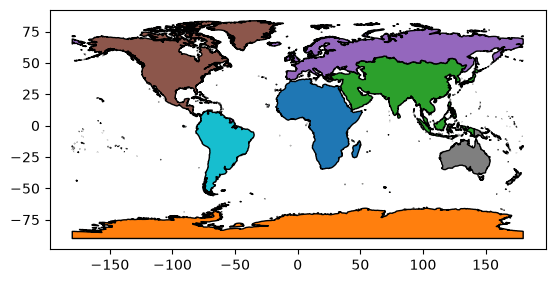

In [97]:
# to colour a plot according to a column, we need to duplicate the index back into a column
continent_gdf['CONTINENT'] = continent_gdf.index

continent_gdf.plot('CONTINENT', edgecolor='black')

Let's try and zoom and make a nice map of Europe. We could filter using a conditional filter on the `CONTINENT` column:

In [98]:
europe_gdf = countries_gdf[countries_gdf['CONTINENT'] == 'Europe']

europe_gdf.head(5) # If we don't want to see all the rows, we can use the `head()` method 
                    # to limit the output to a given number of rows.

,CONTINENT,REGION_UN,SUBREGION,POP_EST,POP_RANK,GDP_MD,INCOME_GRP,ISO_A3,ISO_A2,geometry
ADMIN,,,,,,,,,,
Vatican,Europe,Europe,Southern Europe,825.0,2,-99,2. High income: nonOECD,VAT,VA,"MULTIPOLYGON (((12.43916 41.89839, 12.43057 41..."
Jersey,Europe,Europe,Northern Europe,107800.0,9,5080,2. High income: nonOECD,JEY,JE,"MULTIPOLYGON (((-2.01865 49.23125, -2.00991 49..."
Guernsey,Europe,Europe,Northern Europe,62792.0,8,3465,2. High income: nonOECD,GGY,GG,"MULTIPOLYGON (((-2.5123 49.49453, -2.54736 49...."
Isle of Man,Europe,Europe,Northern Europe,84584.0,8,7491,2. High income: nonOECD,IMN,IM,"MULTIPOLYGON (((-4.41206 54.18535, -4.61426 54..."
United Kingdom,Europe,Europe,Northern Europe,66834405.0,16,2829108,1. High income: OECD,GBR,GB,"MULTIPOLYGON (((-2.66768 51.623, -2.74214 51.5..."


<Axes: >

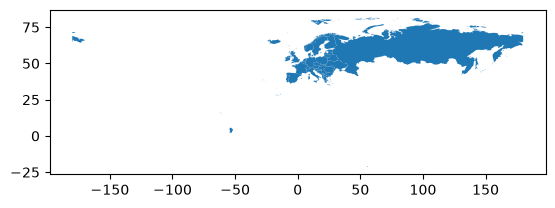

In [77]:
europe_gdf.plot()

This is an excellent way of filtering for certain properties, but might not be our best idea for our aim of making a nice map of Europe. Two countries have messed with our vision: France (whose overseas territories are legally part of Franch, hence the appearance of e.g. French Guinea), and Russia (whose eastern tip appears on the right side of the map). 

To get to our 'vision' of a neat map of Europe, let's use another special `geopandas` function, the `clip` function. Here, we can provide a geodataframe and a geometry, and use the geometry to 'clip' our wider dataset. We will set up a `shapely` `box` function to create a `Polygon` geometry which ranges from -30 - 50˚E and 30 - 70 ˚N. (Note: the clip geometry has to be in the same coordinates as the geodataframe!)

In [125]:

from shapely import box

bounds = -30, 30, 50, 70  # xmin, xmax, ymin, ymax in ˚ lat/lon
bounding_box = box(*bounds)

europe_gdf_clip = gpd.clip(europe_gdf, bounding_box)

<Axes: >

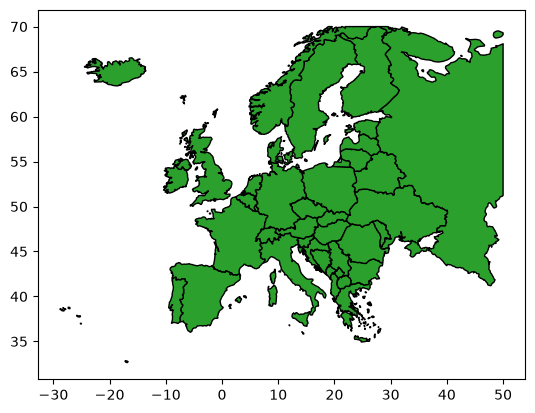

In [ ]:
europe_gdf_clip.plot(
    color='tab:green',  # Let's change the colour from default blue. Countries are green, not blue!
    edgecolor='black'   # Let's add a black border to the countries so that borders are easier to see.
)

Brilliant! Just be aware that that `MultiPolygons` lying outside of the clip box (France, Russia, etc.) have permanently lost data. If you were to rerun a new `area` calculation, this would not accurately determine the size of Russia!

## Writing data to a file.

As with normal pandas dataframes, we can export our `GeoDataFrames` to useful file formats using the `to_file()`. As mentioned above, I would recommend sticking with Geopackages unless you have a specific known reason to use something different - although our filename argument `'.gpkg` should produce a geopackage automatically, specifically setting the `'GPKG'` driver will guarantee your dataset comes out right.

In [ ]:
europe_gdf_clip.to_file('europe_countries_clipped.gpkg', driver='GPKG')

This can now be reloaded into other scripts using Geopandas, or other GIS software such as ArcGIS or QGIS. The CRS metadata will be retained.

## Summary

We have seen how the GeoPandas `GeoDataFrame` extends the Pandas `DataFrame` concept with the `geometry` column, and what this means for our data manipulation and analysis. Next, we will begin to see how we can combine different datasets for more complex relational analysis.